In [1]:
import os
import re
import json
import random
import warnings

import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

warnings.filterwarnings("ignore")

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.14.0
CUDA available: False


In [3]:
MODEL_NAME = "distilbert-base-uncased"

MAX_LENGTH = 256

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

OUTPUT_DIR = "./subscription_model_output"
FINAL_MODEL_DIR = "./final_subscription_model"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

In [4]:
DATASET_PATH = "synthetic_sri_lankan_subscription_dataset_3000_harder.csv"

df = pd.read_csv(DATASET_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (3000, 9)


,id,customer_id,text,label,service,amount,currency,date,frequency
0,EML00001,CUST0053,Payment of $12.85 was processed for your Micro...,1,Microsoft 365,12.85,USD,2026-03-29,monthly
1,EML00002,CUST0176,Payment of $12.30 was processed for your Micro...,1,Microsoft 365,12.30,USD,2026-01-22,monthly
2,EML00003,CUST0248,"Uber receipt: transaction amount LKR 42,307.",0,Uber,42307.00,LKR,2026-06-22,one-time
3,EML00004,CUST0252,Your PickMe transaction was completed for LKR ...,0,PickMe,53964.00,LKR,2026-06-20,one-time
4,EML00005,CUST0241,Your payment of $8.72 for Microsoft 365 was re...,1,Microsoft 365,8.72,USD,2026-04-22,monthly


In [5]:
required_columns = [
    "customer_id",
    "text",
    "label",
    "service",
    "amount",
    "currency",
    "date"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

print("Required columns available.")

Required columns available.


In [6]:
print("\nClass distribution:")
print(df["label"].value_counts())

print("\nMissing values:")
print(df[required_columns].isnull().sum())

print("\nUnique customers:")
print(df["customer_id"].nunique())

print("\nUnique services:")
print(df["service"].nunique())


Class distribution:
label
1    1500
0    1500
Name: count, dtype: int64

Missing values:
customer_id    0
text           0
label          0
service        0
amount         0
currency       0
date           0
dtype: int64

Unique customers:
299

Unique services:
27


In [7]:
df["text"] = df["text"].astype(str)
df["service"] = df["service"].astype(str)
df["currency"] = df["currency"].astype(str)

df["label"] = pd.to_numeric(
    df["label"],
    errors="coerce"
).astype(int)

df["amount"] = pd.to_numeric(
    df["amount"],
    errors="coerce"
)

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

In [8]:
df = df.dropna(
    subset=[
        "customer_id",
        "text",
        "label",
        "date"
    ]
).reset_index(drop=True)

print(df.shape)

(3000, 9)


In [9]:
def preprocess_email(text):

    if pd.isna(text):
        return ""

    text = str(text)

    # Remove HTML
    text = re.sub(
        r"<[^>]+>",
        " ",
        text
    )

    # Remove URLs
    text = re.sub(
        r"http\S+|www\.\S+",
        " ",
        text
    )

    # Remove email addresses
    text = re.sub(
        r"\S+@\S+",
        " ",
        text
    )

    # Normalize whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [10]:
df["clean_text"] = df["text"].apply(
    preprocess_email
)

display(
    df[
        ["text", "clean_text"]
    ].head()
)

,text,clean_text
0,Payment of $12.85 was processed for your Micro...,Payment of $12.85 was processed for your Micro...
1,Payment of $12.30 was processed for your Micro...,Payment of $12.30 was processed for your Micro...
2,"Uber receipt: transaction amount LKR 42,307.","Uber receipt: transaction amount LKR 42,307."
3,Your PickMe transaction was completed for LKR ...,Your PickMe transaction was completed for LKR ...
4,Your payment of $8.72 for Microsoft 365 was re...,Your payment of $8.72 for Microsoft 365 was re...


In [11]:
services = (
    df["service"]
    .dropna()
    .astype(str)
    .unique()
)

services = sorted(
    services,
    key=len,
    reverse=True
)

In [12]:
def mask_service_name(text):

    result = str(text)

    for service in services:

        if not service.strip():
            continue

        result = re.sub(
            re.escape(service),
            "<vendor>",
            result,
            flags=re.IGNORECASE
        )

    return result

In [13]:
df["model_text"] = df["clean_text"].apply(
    mask_service_name
)

In [14]:
display(
    df[
        ["service", "clean_text", "model_text"]
    ].head(10)
)

,service,clean_text,model_text
0,Microsoft 365,Payment of $12.85 was processed for your Micro...,Payment of $12.85 was processed for your <vend...
1,Microsoft 365,Payment of $12.30 was processed for your Micro...,Payment of $12.30 was processed for your <vend...
2,Uber,"Uber receipt: transaction amount LKR 42,307.","<vendor> receipt: transaction amount LKR 42,307."
3,PickMe,Your PickMe transaction was completed for LKR ...,Your <vendor> transaction was completed for LK...
4,Microsoft 365,Your payment of $8.72 for Microsoft 365 was re...,Your payment of $8.72 for <vendor> was receive...
5,ChatGPT Plus,Billing confirmation for ChatGPT Plus: $20.00.,Billing confirmation for <vendor>: $20.00.
6,Adobe Creative Cloud,Your payment of $41.87 for Adobe Creative Clou...,Your payment of $41.87 for <vendor> was receiv...
7,Figma,Your Figma account was charged $30.72. The cur...,Your <vendor> account was charged $30.72. The ...
8,Spotify Premium,Billing confirmation for Spotify Premium: $7.13.,Billing confirmation for <vendor>: $7.13.
9,Microsoft 365,Billing confirmation for Microsoft 365: $11.13.,Billing confirmation for <vendor>: $11.13.


In [15]:
df["duplicate_key"] = (
    df["model_text"]
    .str.lower()
    .str.strip()
)

In [16]:
print(
    "Duplicate texts:",
    df["duplicate_key"].duplicated().sum()
)

Duplicate texts: 159


In [17]:
df = (
    df
    .drop_duplicates(
        subset=["duplicate_key"],
        keep="first"
    )
    .reset_index(drop=True)
)

print(
    "After duplicate removal:",
    df.shape
)

After duplicate removal: (2841, 12)


In [18]:
gss1 = GroupShuffleSplit(
    n_splits=1,
    train_size=TRAIN_RATIO,
    random_state=SEED
)

train_idx, temp_idx = next(
    gss1.split(
        df,
        groups=df["customer_id"]
    )
)

train_df = df.iloc[train_idx].copy()
temp_df = df.iloc[temp_idx].copy()

In [19]:
relative_val_ratio = (
    VAL_RATIO /
    (VAL_RATIO + TEST_RATIO)
)

gss2 = GroupShuffleSplit(
    n_splits=1,
    train_size=relative_val_ratio,
    random_state=SEED
)

val_idx, test_idx = next(
    gss2.split(
        temp_df,
        groups=temp_df["customer_id"]
    )
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

In [20]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [21]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (2039, 12)
Validation: (440, 12)
Test: (362, 12)


In [22]:
train_customers = set(
    train_df["customer_id"]
)

val_customers = set(
    val_df["customer_id"]
)

test_customers = set(
    test_df["customer_id"]
)

print(
    "Train ∩ Validation:",
    len(train_customers & val_customers)
)

print(
    "Train ∩ Test:",
    len(train_customers & test_customers)
)

print(
    "Validation ∩ Test:",
    len(val_customers & test_customers)
)

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [23]:
def print_distribution(name, data):

    print(f"\n{name}")

    print(
        data["label"]
        .value_counts(normalize=True)
        .sort_index()
    )


print_distribution(
    "Train",
    train_df
)

print_distribution(
    "Validation",
    val_df
)

print_distribution(
    "Test",
    test_df
)


Train
label
0    0.535066
1    0.464934
Name: proportion, dtype: float64

Validation
label
0    0.472727
1    0.527273
Name: proportion, dtype: float64

Test
label
0    0.544199
1    0.455801
Name: proportion, dtype: float64


In [24]:
# ============================================================
# BASELINE MODELS
# TF-IDF + LOGISTIC REGRESSION
# TF-IDF + LINEAR SVM
# ============================================================

import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 1. Prepare data
# IMPORTANT: use existing customer-level split
# ------------------------------------------------------------

X_train = train_df["clean_text"].astype(str)
y_train = train_df["label"].astype(int)

X_val = val_df["clean_text"].astype(str)
y_val = val_df["label"].astype(int)

X_test = test_df["clean_text"].astype(str)
y_test = test_df["label"].astype(int)

print("Train samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))


# ------------------------------------------------------------
# 2. TF-IDF
# Fit ONLY on training data
# ------------------------------------------------------------

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF feature count:", X_train_tfidf.shape[1])


# ============================================================
# 3. LOGISTIC REGRESSION
# ============================================================

logistic_model = LogisticRegression(
    max_iter=300,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test_tfidf
)


# ============================================================
# 4. LINEAR SVM
# ============================================================

svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_pred = svm_model.predict(
    X_test_tfidf
)


# ============================================================
# 5. EVALUATION FUNCTION
# ============================================================

def evaluate_model(name, y_true, y_pred):

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }


# ============================================================
# 6. BASELINE RESULTS
# ============================================================

baseline_results = []

baseline_results.append(
    evaluate_model(
        "TF-IDF + Logistic Regression",
        y_test,
        logistic_pred
    )
)

baseline_results.append(
    evaluate_model(
        "TF-IDF + Linear SVM",
        y_test,
        svm_pred
    )
)

baseline_results_df = pd.DataFrame(
    baseline_results
)

print("\nBASELINE MODEL RESULTS")
display(
    baseline_results_df.round(4)
)

Train samples: 2039
Validation samples: 440
Test samples: 362

TF-IDF feature count: 4306

BASELINE MODEL RESULTS


,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF + Logistic Regression,1.0,1.0,1.0,1.0
1,TF-IDF + Linear SVM,1.0,1.0,1.0,1.0


In [25]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

In [26]:
train_dataset = Dataset.from_pandas(
    train_df[
        ["model_text", "label"]
    ],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[
        ["model_text", "label"]
    ],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[
        ["model_text", "label"]
    ],
    preserve_index=False
)

In [27]:
def tokenize_function(batch):

    return tokenizer(
        batch["model_text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

In [28]:
train_ds = train_dataset.map(
    tokenize_function,
    batched=True
)

val_ds = val_dataset.map(
    tokenize_function,
    batched=True
)

test_ds = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/2039 [00:00<?, ? examples/s]

Map:   0%|          | 0/440 [00:00<?, ? examples/s]

Map:   0%|          | 0/362 [00:00<?, ? examples/s]

In [29]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [30]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [31]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    probabilities = torch.softmax(
        torch.tensor(logits),
        dim=1
    ).numpy()

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    subscription_probs = probabilities[:, 1]

    results = {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),

        "precision": precision_score(
            labels,
            predictions,
            zero_division=0
        ),

        "recall": recall_score(
            labels,
            predictions,
            zero_division=0
        ),

        "f1": f1_score(
            labels,
            predictions,
            zero_division=0
        )
    }

    try:
        results["roc_auc"] = roc_auc_score(
            labels,
            subscription_probs
        )
    except:
        results["roc_auc"] = 0.0

    return results

In [32]:
training_kwargs = dict(

    output_dir=OUTPUT_DIR,

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=32,

    num_train_epochs=3,

    weight_decay=0.01,

    save_strategy="epoch",

    logging_strategy="steps",

    logging_steps=20,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    save_total_limit=2,

    report_to="none",

    seed=SEED
)

In [33]:
try:

    training_args = TrainingArguments(
        **training_kwargs,
        eval_strategy="epoch"
    )

except TypeError:

    training_args = TrainingArguments(
        **training_kwargs,
        evaluation_strategy="epoch"
    )

In [34]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_ds,

    eval_dataset=val_ds,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [35]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.003285,0.002017,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.001369,0.000883,1.000000,1.000000,1.000000,1.000000,1.000000
3,0.001042,0.000701,1.000000,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=384, training_loss=0.03319436181724692, metrics={'train_runtime': 84.5578, 'train_samples_per_second': 72.341, 'train_steps_per_second': 4.541, 'total_flos': 41238498318708.0, 'train_loss': 0.03319436181724692, 'epoch': 3.0})

In [36]:
validation_metrics = trainer.evaluate(
    val_ds
)

print(validation_metrics)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Roc Auc
0.001042,0.002017,3,1.000000,1.000000,1.000000,1.000000,1.000000


{'eval_loss': 0.0020174735691398382, 'eval_accuracy': 1.0, 'eval_precision': 1.0, 'eval_recall': 1.0, 'eval_f1': 1.0, 'eval_roc_auc': 1.0}


In [37]:
def generate_text_scores(
    trainer,
    dataset
):

    output = trainer.predict(
        dataset
    )

    logits = output.predictions

    probs = torch.softmax(
        torch.tensor(logits),
        dim=1
    ).numpy()

    return probs[:, 1]

In [38]:
train_df["text_score"] = generate_text_scores(
    trainer,
    train_ds
)

val_df["text_score"] = generate_text_scores(
    trainer,
    val_ds
)

test_df["text_score"] = generate_text_scores(
    trainer,
    test_ds
)

In [39]:
display(
    val_df[
        [
            "service",
            "label",
            "text_score"
        ]
    ].head(10)
)

,service,label,text_score
0,Microsoft 365,1,0.998095
1,ChatGPT Plus,1,0.997976
2,Spotify Premium,1,0.998013
3,NWSDB,0,0.001967
4,Microsoft 365,1,0.998075
5,Google One,1,0.998020
6,LECO,0,0.001960
7,Daraz,0,0.001893
8,CEB,0,0.001942
9,Netflix,1,0.998092


In [40]:
EXTRACTION_FIELDS = [
    "service",
    "amount",
    "currency",
    "transaction_date",
    "renewal_date",
    "billing_cycle",
    "transaction_type"
]

In [41]:
LLM_EXTRACTION_PROMPT = """
You are a financial email information extraction system.

Extract only information explicitly stated in the email.

Return valid JSON only.

Fields:
service
amount
currency
transaction_date
renewal_date
billing_cycle
transaction_type

transaction_type must be one of:
subscription
one_time_purchase
utility_bill
food_order
transport
other

Rules:
- Do not guess missing values.
- Return null when information is unavailable.
- A receipt or payment alone does not mean subscription.
- Subscription requires renewal, recurring billing,
  membership, billing-cycle, or equivalent evidence.

EMAIL:
{email}
"""

In [42]:
STRONG_RECURRING_PHRASES = [
    "subscription",
    "membership",
    "automatically renew",
    "auto renew",
    "auto-renew",
    "recurring payment",
    "next billing",
    "next payment",
    "next renewal",
    "renewal date",
    "renews on"
]

BILLING_CYCLE_PHRASES = [
    "weekly",
    "monthly",
    "every month",
    "quarterly",
    "annual",
    "annually",
    "yearly",
    "every year"
]

ONE_TIME_PHRASES = [
    "thanks for ordering",
    "your order",
    "order completed",
    "restaurant",
    "delivered",
    "delivery completed",
    "ride completed",
    "shipped",
    "one-time purchase",
    "one time purchase"
]

In [43]:
def interval_strength(days):

    if pd.isna(days):
        return 0.0

    days = abs(float(days))

    patterns = [
        (7, 2),
        (30, 5),
        (90, 10),
        (365, 25)
    ]

    best = 0.0

    for target, tolerance in patterns:

        difference = abs(
            days - target
        )

        if difference <= tolerance:

            strength = (
                1 -
                difference /
                (tolerance + 1)
            )

            best = max(
                best,
                strength
            )

    return best

In [44]:
def calculate_recurrence_score(
    current_row,
    history_df
):

    score = 0.0

    text = str(
        current_row["clean_text"]
    ).lower()

    # ---------------------------------
    # 1. Strong recurrence language
    # ---------------------------------

    strong_hits = sum(
        phrase in text
        for phrase in STRONG_RECURRING_PHRASES
    )

    if strong_hits > 0:
        score += min(
            0.30,
            strong_hits * 0.10
        )

    # ---------------------------------
    # 2. Billing-cycle language
    # ---------------------------------

    cycle_hits = sum(
        phrase in text
        for phrase in BILLING_CYCLE_PHRASES
    )

    if cycle_hits > 0:
        score += 0.15

    # ---------------------------------
    # 3. Negative one-time evidence
    # ---------------------------------

    negative_hits = sum(
        phrase in text
        for phrase in ONE_TIME_PHRASES
    )

    if negative_hits > 0:
        score -= min(
            0.35,
            negative_hits * 0.12
        )

    # ---------------------------------
    # 4. Historical same service
    # ---------------------------------

    same_history = history_df[
        history_df["service"]
        .astype(str)
        .str.lower()
        ==
        str(current_row["service"]).lower()
    ].copy()

    if not same_history.empty:

        previous = (
            same_history
            .sort_values("date")
            .iloc[-1]
        )

        current_date = current_row["date"]
        previous_date = previous["date"]

        if (
            pd.notna(current_date)
            and
            pd.notna(previous_date)
        ):

            gap = (
                current_date -
                previous_date
            ).days

            score += (
                0.35 *
                interval_strength(gap)
            )

        # Similar amount
        current_amount = current_row["amount"]
        previous_amount = previous["amount"]

        if (
            pd.notna(current_amount)
            and
            pd.notna(previous_amount)
            and
            previous_amount != 0
        ):

            difference = abs(
                current_amount -
                previous_amount
            ) / abs(previous_amount)

            if difference <= 0.10:
                score += 0.20

    return float(
        np.clip(
            score,
            0.0,
            1.0
        )
    )

In [45]:
def add_recurrence_scores(
    target_df,
    initial_history=None
):

    target_df = (
        target_df
        .sort_values(
            ["customer_id", "date"]
        )
        .copy()
    )

    recurrence_scores = {}

    history_by_customer = {}

    # -----------------------------------
    # Load initial historical records
    # -----------------------------------

    if initial_history is not None:

        for customer_id, group in (
            initial_history
            .sort_values("date")
            .groupby("customer_id")
        ):

            history_by_customer[
                customer_id
            ] = group.copy()

    # -----------------------------------
    # Score rows chronologically
    # -----------------------------------

    for idx, row in target_df.iterrows():

        customer_id = row[
            "customer_id"
        ]

        customer_history = (
            history_by_customer.get(
                customer_id,
                pd.DataFrame(
                    columns=target_df.columns
                )
            )
        )

        recurrence_score = (
            calculate_recurrence_score(
                row,
                customer_history
            )
        )

        recurrence_scores[idx] = (
            recurrence_score
        )

        # Add current row only AFTER scoring

        row_df = pd.DataFrame(
            [row]
        )

        if customer_history.empty:

            history_by_customer[
                customer_id
            ] = row_df

        else:

            history_by_customer[
                customer_id
            ] = pd.concat(
                [
                    customer_history,
                    row_df
                ],
                ignore_index=True
            )

    target_df[
        "recurrence_score"
    ] = pd.Series(
        recurrence_scores
    )

    return target_df.sort_index()

In [46]:
train_df = add_recurrence_scores(
    train_df
)

In [47]:
val_df = add_recurrence_scores(
    val_df,
    initial_history=train_df
)

In [48]:
train_val_history = pd.concat(
    [
        train_df,
        val_df
    ],
    ignore_index=True
)

test_df = add_recurrence_scores(
    test_df,
    initial_history=train_val_history
)

In [49]:
display(
    val_df[
        [
            "service",
            "text_score",
            "recurrence_score",
            "label"
        ]
    ].head(20)
)

,service,text_score,recurrence_score,label
0,Microsoft 365,0.998095,0.100000,1
1,ChatGPT Plus,0.997976,0.000000,1
2,Spotify Premium,0.998013,0.350000,1
3,NWSDB,0.001967,0.291667,0
4,Microsoft 365,0.998075,0.233333,1
5,Google One,0.998020,0.291667,1
6,LECO,0.001960,0.000000,0
7,Daraz,0.001893,0.000000,0
8,CEB,0.001942,0.000000,0
9,Netflix,0.998092,0.100000,1


In [50]:
text_predictions = (
    val_df["text_score"] >= 0.50
).astype(int)

print(
    classification_report(
        val_df["label"],
        text_predictions,
        target_names=[
            "Non-Subscription",
            "Subscription"
        ]
    )
)

                  precision    recall  f1-score   support

Non-Subscription       1.00      1.00      1.00       208
    Subscription       1.00      1.00      1.00       232

        accuracy                           1.00       440
       macro avg       1.00      1.00      1.00       440
    weighted avg       1.00      1.00      1.00       440



In [51]:
recurrence_predictions = (
    val_df["recurrence_score"]
    >= 0.50
).astype(int)

print(
    classification_report(
        val_df["label"],
        recurrence_predictions,
        target_names=[
            "Non-Subscription",
            "Subscription"
        ],
        zero_division=0
    )
)

                  precision    recall  f1-score   support

Non-Subscription       0.48      0.99      0.65       208
    Subscription       0.87      0.06      0.11       232

        accuracy                           0.50       440
       macro avg       0.68      0.52      0.38       440
    weighted avg       0.69      0.50      0.36       440



In [52]:
weights = np.arange(
    0.0,
    1.01,
    0.05
)

thresholds = np.arange(
    0.10,
    0.91,
    0.01
)

validation_results = []

In [53]:
for recurrence_weight in weights:

    text_weight = (
        1.0 -
        recurrence_weight
    )

    hybrid_score = (
        text_weight
        *
        val_df["text_score"].astype(float)

        +

        recurrence_weight
        *
        val_df[
            "recurrence_score"
        ].astype(float)
    )

    for threshold in thresholds:

        prediction = (
            hybrid_score >= threshold
        ).astype(int)

        validation_results.append(
            {
                "text_weight":
                    text_weight,

                "recurrence_weight":
                    recurrence_weight,

                "threshold":
                    threshold,

                "accuracy":
                    accuracy_score(
                        val_df["label"],
                        prediction
                    ),

                "precision":
                    precision_score(
                        val_df["label"],
                        prediction,
                        zero_division=0
                    ),

                "recall":
                    recall_score(
                        val_df["label"],
                        prediction,
                        zero_division=0
                    ),

                "f1":
                    f1_score(
                        val_df["label"],
                        prediction,
                        zero_division=0
                    )
            }
        )

In [54]:
validation_results_df = pd.DataFrame(
    validation_results
)

In [55]:
best_row = (
    validation_results_df
    .sort_values(
        [
            "f1",
            "precision",
            "recall",
            "accuracy"
        ],
        ascending=False
    )
    .iloc[0]
)

print(best_row)

text_weight          1.0
recurrence_weight    0.0
threshold            0.1
accuracy             1.0
precision            1.0
recall               1.0
f1                   1.0
Name: 0, dtype: float64


In [56]:
BEST_TEXT_WEIGHT = float(
    best_row["text_weight"]
)

BEST_RECURRENCE_WEIGHT = float(
    best_row["recurrence_weight"]
)

BEST_THRESHOLD = float(
    best_row["threshold"]
)

print(
    "Text weight:",
    BEST_TEXT_WEIGHT
)

print(
    "Recurrence weight:",
    BEST_RECURRENCE_WEIGHT
)

print(
    "Binary threshold:",
    BEST_THRESHOLD
)

Text weight: 1.0
Recurrence weight: 0.0
Binary threshold: 0.1


In [57]:
def create_hybrid_score(
    dataframe,
    text_weight,
    recurrence_weight
):

    return (
        text_weight
        *
        dataframe["text_score"]

        +

        recurrence_weight
        *
        dataframe[
            "recurrence_score"
        ]
    )

In [58]:
val_df["hybrid_score"] = (
    create_hybrid_score(
        val_df,
        BEST_TEXT_WEIGHT,
        BEST_RECURRENCE_WEIGHT
    )
)

In [59]:
test_df["hybrid_score"] = (
    create_hybrid_score(
        test_df,
        BEST_TEXT_WEIGHT,
        BEST_RECURRENCE_WEIGHT
    )
)

In [60]:
test_df[
    "final_prediction"
] = (
    test_df["hybrid_score"]
    >= BEST_THRESHOLD
).astype(int)

In [61]:
test_accuracy = accuracy_score(
    test_df["label"],
    test_df["final_prediction"]
)

test_precision = precision_score(
    test_df["label"],
    test_df["final_prediction"],
    zero_division=0
)

test_recall = recall_score(
    test_df["label"],
    test_df["final_prediction"],
    zero_division=0
)

test_f1 = f1_score(
    test_df["label"],
    test_df["final_prediction"],
    zero_division=0
)

test_auc = roc_auc_score(
    test_df["label"],
    test_df["hybrid_score"]
)

print(
    "Accuracy :",
    round(test_accuracy, 4)
)

print(
    "Precision:",
    round(test_precision, 4)
)

print(
    "Recall   :",
    round(test_recall, 4)
)

print(
    "F1 Score :",
    round(test_f1, 4)
)

print(
    "ROC-AUC  :",
    round(test_auc, 4)
)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0


In [62]:
print(
    classification_report(
        test_df["label"],
        test_df["final_prediction"],
        target_names=[
            "Non-Subscription",
            "Subscription"
        ],
        zero_division=0
    )
)

                  precision    recall  f1-score   support

Non-Subscription       1.00      1.00      1.00       197
    Subscription       1.00      1.00      1.00       165

        accuracy                           1.00       362
       macro avg       1.00      1.00      1.00       362
    weighted avg       1.00      1.00      1.00       362



In [63]:
cm = confusion_matrix(
    test_df["label"],
    test_df["final_prediction"]
)

print(cm)

[[197   0]
 [  0 165]]


In [64]:
false_positives = test_df[
    (test_df["label"] == 0)
    &
    (
        test_df[
            "final_prediction"
        ] == 1
    )
].copy()

In [65]:
false_negatives = test_df[
    (test_df["label"] == 1)
    &
    (
        test_df[
            "final_prediction"
        ] == 0
    )
].copy()

In [66]:
display(
    false_positives[
        [
            "text",
            "service",
            "text_score",
            "recurrence_score",
            "hybrid_score"
        ]
    ].head(20)
)

,text,service,text_score,recurrence_score,hybrid_score


In [67]:
display(
    false_negatives[
        [
            "text",
            "service",
            "text_score",
            "recurrence_score",
            "hybrid_score"
        ]
    ].head(20)
)

,text,service,text_score,recurrence_score,hybrid_score


In [68]:
NORMAL_THRESHOLD = 0.30
AUTO_ADD_THRESHOLD = 0.75

In [69]:
def confidence_classification(
    hybrid_score
):

    if hybrid_score >= AUTO_ADD_THRESHOLD:

        return "Subscription"

    elif hybrid_score <= NORMAL_THRESHOLD:

        return "Normal"

    else:

        return "Uncertain"

In [70]:
def decision_engine(
    hybrid_score
):

    classification = (
        confidence_classification(
            hybrid_score
        )
    )

    if classification == "Subscription":

        return "AUTO_ADD"

    elif classification == "Uncertain":

        return "ASK_USER"

    else:

        return "ASK_USER"

In [71]:
IGNORE_THRESHOLD = 0.10

In [72]:
def decision_engine(
    hybrid_score
):

    if hybrid_score < IGNORE_THRESHOLD:

        return "IGNORE"

    if hybrid_score >= AUTO_ADD_THRESHOLD:

        return "AUTO_ADD"

    return "ASK_USER"

In [73]:
def safety_validation(
    service,
    amount,
    currency,
    hybrid_score,
    user_confirmed=False
):

    if (
        service is None
        or
        str(service).strip() == ""
    ):

        return False, "Service missing"

    try:

        amount = float(amount)

    except:

        return False, "Invalid amount"

    if amount <= 0:

        return False, "Amount must be greater than zero"

    if (
        currency is None
        or
        str(currency).strip() == ""
    ):

        return False, "Currency missing"

    # User confirmation overrides
    # automatic confidence threshold

    if user_confirmed:

        return True, "Valid"

    if hybrid_score < AUTO_ADD_THRESHOLD:

        return (
            False,
            "Insufficient confidence for automatic add"
        )

    return True, "Valid"

In [74]:
def is_duplicate_subscription(
    service,
    amount,
    currency,
    billing_cycle,
    existing_subscriptions
):

    if existing_subscriptions.empty:
        return False

    matches = existing_subscriptions[
        (
            existing_subscriptions[
                "service"
            ]
            .astype(str)
            .str.lower()
            ==
            str(service).lower()
        )
        &
        (
            np.isclose(
                existing_subscriptions[
                    "amount"
                ].astype(float),
                float(amount),
                rtol=0.05
            )
        )
        &
        (
            existing_subscriptions[
                "currency"
            ]
            .astype(str)
            .str.upper()
            ==
            str(currency).upper()
        )
    ]

    if billing_cycle:

        matches = matches[
            matches[
                "billing_cycle"
            ]
            .astype(str)
            .str.lower()
            ==
            str(billing_cycle).lower()
        ]

    return not matches.empty

In [75]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = trainer.model.to(device)
model.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

In [76]:
def predict_text_score(
    email_text
):

    clean = preprocess_email(
        email_text
    )

    masked = mask_service_name(
        clean
    )

    inputs = tokenizer(
        masked,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
        padding=True
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model(
            **inputs
        )

        probabilities = torch.softmax(
            outputs.logits,
            dim=1
        )

    return float(
        probabilities[
            0,
            1
        ].cpu()
    )

In [77]:
def final_subscription_prediction(
    email_text,
    service,
    amount,
    currency,
    date,
    history_df,
    billing_cycle=None
):

    # -----------------------------------
    # 1. Text score
    # -----------------------------------

    text_score = predict_text_score(
        email_text
    )

    # -----------------------------------
    # 2. Current row
    # -----------------------------------

    current_row = pd.Series(
        {
            "clean_text":
                preprocess_email(
                    email_text
                ),

            "service":
                service,

            "amount":
                amount,

            "currency":
                currency,

            "date":
                pd.to_datetime(
                    date
                )
        }
    )

    # -----------------------------------
    # 3. Recurrence score
    # -----------------------------------

    recurrence_score = (
        calculate_recurrence_score(
            current_row,
            history_df
        )
    )

    # -----------------------------------
    # 4. Hybrid score
    # -----------------------------------

    hybrid_score = (
        BEST_TEXT_WEIGHT
        *
        text_score

        +

        BEST_RECURRENCE_WEIGHT
        *
        recurrence_score
    )

    # -----------------------------------
    # 5. Classification
    # -----------------------------------

    classification = (
        confidence_classification(
            hybrid_score
        )
    )

    # -----------------------------------
    # 6. Decision Engine
    # -----------------------------------

    decision = decision_engine(
        hybrid_score
    )

    return {

        "service":
            service,

        "amount":
            amount,

        "currency":
            currency,

        "billing_cycle":
            billing_cycle,

        "text_score":
            round(
                text_score,
                4
            ),

        "recurrence_score":
            round(
                recurrence_score,
                4
            ),

        "hybrid_score":
            round(
                hybrid_score,
                4
            ),

        "classification":
            classification,

        "decision":
            decision
    }

In [78]:
history = pd.DataFrame(
    [
        {
            "service": "Netflix",
            "amount": 15.99,
            "currency": "USD",
            "date": pd.Timestamp(
                "2026-07-15"
            )
        },

        {
            "service": "Netflix",
            "amount": 15.99,
            "currency": "USD",
            "date": pd.Timestamp(
                "2026-08-15"
            )
        }
    ]
)

In [79]:
result = final_subscription_prediction(

    email_text="""
    Your Netflix membership will
    automatically renew on September 15.
    Your monthly subscription price is
    USD 15.99.
    """,

    service="Netflix",

    amount=15.99,

    currency="USD",

    date="2026-09-15",

    history_df=history,

    billing_cycle="monthly"
)

print(
    json.dumps(
        result,
        indent=4
    )
)

{
    "service": "Netflix",
    "amount": 15.99,
    "currency": "USD",
    "billing_cycle": "monthly",
    "text_score": 0.9648,
    "recurrence_score": 0.9417,
    "hybrid_score": 0.9648,
    "classification": "Subscription",
    "decision": "AUTO_ADD"
}


In [80]:
uber_history = pd.DataFrame(
    columns=[
        "service",
        "amount",
        "currency",
        "date"
    ]
)

In [81]:
result = final_subscription_prediction(

    email_text="""
    Thanks for ordering with Uber Eats.
    Your order from Vanni Inn Restaurant
    has been completed.
    Total LKR 1504.35.
    """,

    service="Uber Eats",

    amount=1504.35,

    currency="LKR",

    date="2026-06-30",

    history_df=uber_history,

    billing_cycle=None
)

print(
    json.dumps(
        result,
        indent=4
    )
)

{
    "service": "Uber Eats",
    "amount": 1504.35,
    "currency": "LKR",
    "billing_cycle": null,
    "text_score": 0.0828,
    "recurrence_score": 0.0,
    "hybrid_score": 0.0828,
    "classification": "Normal",
    "decision": "IGNORE"
}


In [82]:
def process_user_decision(
    model_result,
    user_choice
):

    user_choice = (
        user_choice
        .strip()
        .lower()
    )

    if user_choice == "ignore":

        return {
            "save": False,
            "final_type": "Ignore"
        }

    if user_choice == "normal":

        return {
            "save": True,
            "final_type": "Normal Transaction",
            "destination": "Expense Table"
        }

    if user_choice == "subscription":

        valid, message = (
            safety_validation(

                service=
                    model_result[
                        "service"
                    ],

                amount=
                    model_result[
                        "amount"
                    ],

                currency=
                    model_result[
                        "currency"
                    ],

                hybrid_score=
                    model_result[
                        "hybrid_score"
                    ],

                user_confirmed=True
            )
        )

        return {

            "save": valid,

            "final_type":
                "Subscription",

            "destination":
                "Subscription Table"
                if valid
                else None,

            "message":
                message
        }

    return {
        "save": False,
        "message": "Invalid user choice"
    }

In [83]:
MODEL_SAVE_PATH = os.path.join(
    FINAL_MODEL_DIR,
    "transformer"
)

trainer.save_model(
    MODEL_SAVE_PATH
)

tokenizer.save_pretrained(
    MODEL_SAVE_PATH
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./final_subscription_model/transformer/tokenizer_config.json',
 './final_subscription_model/transformer/tokenizer.json')

In [84]:
configuration = {

    "transformer_model":
        MODEL_NAME,

    "text_weight":
        BEST_TEXT_WEIGHT,

    "recurrence_weight":
        BEST_RECURRENCE_WEIGHT,

    "binary_threshold":
        BEST_THRESHOLD,

    "normal_threshold":
        NORMAL_THRESHOLD,

    "ignore_threshold":
        IGNORE_THRESHOLD,

    "auto_add_threshold":
        AUTO_ADD_THRESHOLD,

    "max_length":
        MAX_LENGTH
}

In [85]:
CONFIG_PATH = os.path.join(
    FINAL_MODEL_DIR,
    "configuration.json"
)

with open(
    CONFIG_PATH,
    "w"
) as f:

    json.dump(
        configuration,
        f,
        indent=4
    )

print(
    "Configuration saved:",
    CONFIG_PATH
)

Configuration saved: ./final_subscription_model/configuration.json


In [86]:
prediction_columns = [
    "customer_id",
    "service",
    "amount",
    "currency",
    "date",
    "label",
    "text_score",
    "recurrence_score",
    "hybrid_score",
    "final_prediction"
]

test_df[
    prediction_columns
].to_csv(
    os.path.join(
        FINAL_MODEL_DIR,
        "final_test_predictions.csv"
    ),
    index=False
)

In [87]:
final_metrics = {

    "accuracy":
        float(test_accuracy),

    "precision":
        float(test_precision),

    "recall":
        float(test_recall),

    "f1":
        float(test_f1),

    "roc_auc":
        float(test_auc),

    "confusion_matrix":
        cm.tolist()
}

In [88]:
with open(
    os.path.join(
        FINAL_MODEL_DIR,
        "final_metrics.json"
    ),
    "w"
) as f:

    json.dump(
        final_metrics,
        f,
        indent=4
    )

In [89]:
normal_thresholds = np.arange(0.10, 0.51, 0.05)
auto_add_thresholds = np.arange(0.50, 0.96, 0.05)

decision_threshold_results = []

y_true = val_df["label"].astype(int).to_numpy()
scores = val_df["hybrid_score"].astype(float).to_numpy()

for normal_threshold in normal_thresholds:

    for auto_add_threshold in auto_add_thresholds:

        if normal_threshold >= auto_add_threshold:
            continue

        decisions = np.where(
            scores >= auto_add_threshold,
            "AUTO_ADD",
            np.where(
                scores <= normal_threshold,
                "NORMAL",
                "ASK_USER"
            )
        )

        auto_mask = decisions == "AUTO_ADD"
        normal_mask = decisions == "NORMAL"
        ask_mask = decisions == "ASK_USER"

        # Correct AUTO_ADD:
        # prediction is Subscription and actual label is 1
        auto_correct = np.sum(
            auto_mask & (y_true == 1)
        )

        # Correct NORMAL:
        # prediction is Normal and actual label is 0
        normal_correct = np.sum(
            normal_mask & (y_true == 0)
        )

        auto_precision = (
            auto_correct / np.sum(auto_mask)
            if np.sum(auto_mask) > 0
            else 0.0
        )

        normal_precision = (
            normal_correct / np.sum(normal_mask)
            if np.sum(normal_mask) > 0
            else 0.0
        )

        automatic_mask = auto_mask | normal_mask

        automatic_correct = np.sum(
            (auto_mask & (y_true == 1))
            |
            (normal_mask & (y_true == 0))
        )

        automatic_accuracy = (
            automatic_correct / np.sum(automatic_mask)
            if np.sum(automatic_mask) > 0
            else 0.0
        )

        automatic_coverage = np.mean(automatic_mask)
        ask_user_rate = np.mean(ask_mask)

        false_auto_adds = np.sum(
            auto_mask & (y_true == 0)
        )

        missed_subscriptions = np.sum(
            normal_mask & (y_true == 1)
        )

        decision_threshold_results.append({
            "normal_threshold": round(
                float(normal_threshold), 2
            ),
            "auto_add_threshold": round(
                float(auto_add_threshold), 2
            ),
            "auto_precision": auto_precision,
            "normal_precision": normal_precision,
            "automatic_accuracy": automatic_accuracy,
            "automatic_coverage": automatic_coverage,
            "ask_user_rate": ask_user_rate,
            "false_auto_adds": int(false_auto_adds),
            "missed_subscriptions": int(
                missed_subscriptions
            )
        })

In [90]:
decision_results_df = pd.DataFrame(
    decision_threshold_results
)

safe_results = decision_results_df[
    (decision_results_df["auto_precision"] >= 0.95)
    &
    (decision_results_df["normal_precision"] >= 0.95)
].copy()

if safe_results.empty:

    print(
        "No thresholds satisfy both 95% precision constraints."
    )

    best_decision_row = (
        decision_results_df
        .sort_values(
            [
                "automatic_accuracy",
                "automatic_coverage",
                "auto_precision",
                "normal_precision"
            ],
            ascending=False
        )
        .iloc[0]
    )

else:

    best_decision_row = (
        safe_results
        .sort_values(
            [
                "automatic_coverage",
                "automatic_accuracy",
                "auto_precision",
                "normal_precision"
            ],
            ascending=False
        )
        .iloc[0]
    )

display(best_decision_row)

normal_threshold        0.1
auto_add_threshold      0.5
auto_precision          1.0
normal_precision        1.0
automatic_accuracy      1.0
automatic_coverage      1.0
ask_user_rate           0.0
false_auto_adds         0.0
missed_subscriptions    0.0
Name: 0, dtype: float64

In [91]:
NORMAL_THRESHOLD = float(
    best_decision_row["normal_threshold"]
)

AUTO_ADD_THRESHOLD = float(
    best_decision_row["auto_add_threshold"]
)

print("Final normal threshold:", NORMAL_THRESHOLD)
print("Final auto-add threshold:", AUTO_ADD_THRESHOLD)

Final normal threshold: 0.1
Final auto-add threshold: 0.5


In [92]:
print(
    f"ASK_USER range: "
    f"{NORMAL_THRESHOLD:.2f} < score < "
    f"{AUTO_ADD_THRESHOLD:.2f}"
)

ASK_USER range: 0.10 < score < 0.50


In [93]:
def confidence_classification(hybrid_score):

    hybrid_score = float(hybrid_score)

    if hybrid_score >= AUTO_ADD_THRESHOLD:
        return "Subscription"

    if hybrid_score <= NORMAL_THRESHOLD:
        return "Normal"

    return "Uncertain"

In [94]:
def decision_engine(hybrid_score):

    classification = confidence_classification(
        hybrid_score
    )

    if classification == "Subscription":
        return "AUTO_ADD"

    if classification == "Normal":
        return "NORMAL"

    return "ASK_USER"

In [95]:
val_df["confidence_classification"] = (
    val_df["hybrid_score"].apply(
        confidence_classification
    )
)

val_df["decision"] = (
    val_df["hybrid_score"].apply(
        decision_engine
    )
)

print(
    val_df["decision"].value_counts()
)

display(
    val_df[
        [
            "service",
            "label",
            "text_score",
            "recurrence_score",
            "hybrid_score",
            "confidence_classification",
            "decision"
        ]
    ].head(20)
)

decision
AUTO_ADD    232
NORMAL      208
Name: count, dtype: int64


,service,label,text_score,recurrence_score,hybrid_score,confidence_classification,decision
0,Microsoft 365,1,0.998095,0.100000,0.998095,Subscription,AUTO_ADD
1,ChatGPT Plus,1,0.997976,0.000000,0.997976,Subscription,AUTO_ADD
2,Spotify Premium,1,0.998013,0.350000,0.998013,Subscription,AUTO_ADD
3,NWSDB,0,0.001967,0.291667,0.001967,Normal,NORMAL
4,Microsoft 365,1,0.998075,0.233333,0.998075,Subscription,AUTO_ADD
5,Google One,1,0.998020,0.291667,0.998020,Subscription,AUTO_ADD
6,LECO,0,0.001960,0.000000,0.001960,Normal,NORMAL
7,Daraz,0,0.001893,0.000000,0.001893,Normal,NORMAL
8,CEB,0,0.001942,0.000000,0.001942,Normal,NORMAL
9,Netflix,1,0.998092,0.100000,0.998092,Subscription,AUTO_ADD


In [96]:
FINAL_CONFIGURATION = {
    "transformer_model": MODEL_NAME,
    "text_weight": BEST_TEXT_WEIGHT,
    "recurrence_weight": BEST_RECURRENCE_WEIGHT,
    "binary_threshold": BEST_THRESHOLD,
    "normal_threshold": NORMAL_THRESHOLD,
    "auto_add_threshold": AUTO_ADD_THRESHOLD,
    "max_length": MAX_LENGTH
}

print(
    json.dumps(
        FINAL_CONFIGURATION,
        indent=4
    )
)

{
    "transformer_model": "distilbert-base-uncased",
    "text_weight": 1.0,
    "recurrence_weight": 0.0,
    "binary_threshold": 0.1,
    "normal_threshold": 0.1,
    "auto_add_threshold": 0.5,
    "max_length": 256
}


In [97]:
AUTOMATIC_DECISIONS_ENABLED = not safe_results.empty

FINAL_CONFIGURATION["automatic_decisions_enabled"] = (
    AUTOMATIC_DECISIONS_ENABLED
)

def decision_engine(hybrid_score):

    score = float(hybrid_score)

    if not np.isfinite(score) or not 0 <= score <= 1:
        return "ASK_USER"

    if not AUTOMATIC_DECISIONS_ENABLED:
        return "ASK_USER"

    if score >= AUTO_ADD_THRESHOLD:
        return "AUTO_ADD"

    if score <= NORMAL_THRESHOLD:
        return "NORMAL"

    return "ASK_USER"


print(
    "Automatic decisions enabled:",
    AUTOMATIC_DECISIONS_ENABLED
)

Automatic decisions enabled: True


In [98]:
test_df = test_df.copy()

test_df["hybrid_score"] = (
    BEST_TEXT_WEIGHT * test_df["text_score"].astype(float)
    +
    BEST_RECURRENCE_WEIGHT
    * test_df["recurrence_score"].astype(float)
)

assert len(test_df) > 0, "Test dataset is empty."
assert test_df["label"].isin([0, 1]).all(), "Invalid labels."
assert np.isfinite(test_df["hybrid_score"]).all(), (
    "Test scores contain missing or infinite values."
)
assert test_df["hybrid_score"].between(0, 1).all(), (
    "Test scores must be between 0 and 1."
)

test_df["final_prediction"] = (
    test_df["hybrid_score"] >= BEST_THRESHOLD
).astype(int)

test_df["classification"] = (
    test_df["hybrid_score"].apply(
        confidence_classification
    )
)

test_df["decision"] = (
    test_df["hybrid_score"].apply(decision_engine)
)

display(
    test_df[
        [
            "service",
            "label",
            "text_score",
            "recurrence_score",
            "hybrid_score",
            "classification",
            "decision"
        ]
    ].head(20)
)

,service,label,text_score,recurrence_score,hybrid_score,classification,decision
0,HNB,0,0.001932,0.000000,0.001932,Normal,NORMAL
1,NWSDB,0,0.001882,0.175000,0.001882,Normal,NORMAL
2,Google One,1,0.998062,0.000000,0.998062,Subscription,AUTO_ADD
3,Sampath Bank,0,0.001952,0.000000,0.001952,Normal,NORMAL
4,Sampath Bank,0,0.001954,0.000000,0.001954,Normal,NORMAL
5,ChatGPT Plus,1,0.998059,0.000000,0.998059,Subscription,AUTO_ADD
6,Figma,1,0.998096,0.100000,0.998096,Subscription,AUTO_ADD
7,Dialog,0,0.002075,0.116667,0.002075,Normal,NORMAL
8,CEB,0,0.001909,0.000000,0.001909,Normal,NORMAL
9,Google One,1,0.998043,0.000000,0.998043,Subscription,AUTO_ADD


In [99]:
y_true = test_df["label"].astype(int)
y_pred = test_df["final_prediction"]

auto_mask = test_df["decision"].eq("AUTO_ADD")
normal_mask = test_df["decision"].eq("NORMAL")
ask_mask = test_df["decision"].eq("ASK_USER")

automatic_mask = auto_mask | normal_mask

automatic_correct = (
    (auto_mask & y_true.eq(1))
    |
    (normal_mask & y_true.eq(0))
)

def safe_ratio(numerator, denominator):
    return (
        float(numerator / denominator)
        if denominator > 0
        else None
    )

final_metrics = {
    "binary_classification": {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(
            precision_score(y_true, y_pred, zero_division=0)
        ),
        "recall": float(
            recall_score(y_true, y_pred, zero_division=0)
        ),
        "f1": float(
            f1_score(y_true, y_pred, zero_division=0)
        ),
        "roc_auc": (
            float(
                roc_auc_score(
                    y_true,
                    test_df["hybrid_score"]
                )
            )
            if y_true.nunique() == 2
            else None
        ),
        "confusion_matrix": confusion_matrix(
            y_true, y_pred, labels=[0, 1]
        ).tolist()
    },

    "decision_engine": {
        "total_emails": int(len(test_df)),
        "auto_add_count": int(auto_mask.sum()),
        "normal_count": int(normal_mask.sum()),
        "ask_user_count": int(ask_mask.sum()),

        "auto_add_precision": safe_ratio(
            (auto_mask & y_true.eq(1)).sum(),
            auto_mask.sum()
        ),

        # Negative predictive value:
        # fraction of NORMAL decisions that are truly normal.
        "normal_negative_predictive_value": safe_ratio(
            (normal_mask & y_true.eq(0)).sum(),
            normal_mask.sum()
        ),

        "automatic_accuracy": safe_ratio(
            automatic_correct.sum(),
            automatic_mask.sum()
        ),

        "automatic_coverage": float(
            automatic_mask.mean()
        ),
        "ask_user_rate": float(ask_mask.mean()),

        "false_auto_adds": int(
            (auto_mask & y_true.eq(0)).sum()
        ),
        "subscriptions_marked_normal": int(
            (normal_mask & y_true.eq(1)).sum()
        )
    }
}

print(json.dumps(final_metrics, indent=4, allow_nan=False))

{
    "binary_classification": {
        "accuracy": 1.0,
        "precision": 1.0,
        "recall": 1.0,
        "f1": 1.0,
        "roc_auc": 1.0,
        "confusion_matrix": [
            [
                197,
                0
            ],
            [
                0,
                165
            ]
        ]
    },
    "decision_engine": {
        "total_emails": 362,
        "auto_add_count": 165,
        "normal_count": 197,
        "ask_user_count": 0,
        "auto_add_precision": 1.0,
        "normal_negative_predictive_value": 1.0,
        "automatic_accuracy": 1.0,
        "automatic_coverage": 1.0,
        "ask_user_rate": 0.0,
        "false_auto_adds": 0,
        "subscriptions_marked_normal": 0
    }
}


In [100]:
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

with open(
    os.path.join(FINAL_MODEL_DIR, "configuration.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        FINAL_CONFIGURATION,
        f,
        indent=4,
        allow_nan=False
    )

with open(
    os.path.join(FINAL_MODEL_DIR, "final_metrics.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        final_metrics,
        f,
        indent=4,
        allow_nan=False
    )

test_df[
    [
        "customer_id",
        "service",
        "label",
        "text_score",
        "recurrence_score",
        "hybrid_score",
        "final_prediction",
        "classification",
        "decision"
    ]
].to_csv(
    os.path.join(
        FINAL_MODEL_DIR,
        "final_test_predictions.csv"
    ),
    index=False
)

print("Updated configuration and test results saved.")

Updated configuration and test results saved.


In [101]:
import os
import json

preprocessing_config = {
    "vendor_masking": True,
    "services": [str(service) for service in services],
    "subscription_label_id": 1,
    "max_length": int(MAX_LENGTH)
}

with open(
    os.path.join(
        FINAL_MODEL_DIR,
        "preprocessing_config.json"
    ),
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        preprocessing_config,
        f,
        indent=4,
        ensure_ascii=False
    )

print("Preprocessing settings saved.")

Preprocessing settings saved.


In [103]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

import pandas as pd

# True labels
y_test = test_df["label"].astype(int)

# ------------------------------------------------------------
# 1. DistilBERT text-only prediction
# Use the SAME optimized binary threshold
# ------------------------------------------------------------

distilbert_prediction = (
    test_df["text_score"].astype(float) >= BEST_THRESHOLD
).astype(int)


# ------------------------------------------------------------
# 2. Recurrence-only prediction
# Fixed threshold = 0.50
# ------------------------------------------------------------

recurrence_prediction = (
    test_df["recurrence_score"].astype(float) >= 0.50
).astype(int)


# ------------------------------------------------------------
# 3. Optimized Hybrid prediction
# Already calculated in notebook
# ------------------------------------------------------------

final_hybrid_prediction = (
    test_df["final_prediction"].astype(int)
)


# ------------------------------------------------------------
# 4. Combine all model results
# ------------------------------------------------------------

all_results = baseline_results.copy()

all_results.append(
    evaluate_model(
        "DistilBERT (Text Only)",
        y_test,
        distilbert_prediction
    )
)

all_results.append(
    evaluate_model(
        "Recurrence Only (Threshold = 0.50)",
        y_test,
        recurrence_prediction
    )
)

all_results.append(
    evaluate_model(
        "Optimized Hybrid",
        y_test,
        final_hybrid_prediction
    )
)


# ------------------------------------------------------------
# 5. Create comparison table
# ------------------------------------------------------------

comparison_df = pd.DataFrame(all_results)

comparison_df = comparison_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
]

print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

display(
    comparison_df.round(4)
)

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF + Logistic Regression,1.000,1.0,1.0000,1.0000
1,TF-IDF + Linear SVM,1.000,1.0,1.0000,1.0000
2,DistilBERT (Text Only),1.000,1.0,1.0000,1.0000
3,Recurrence Only (Threshold = 0.50),0.558,1.0,0.0303,0.0588
4,Optimized Hybrid,1.000,1.0,1.0000,1.0000


TF-IDF + Logistic Regression
TN: 197
FP: 0
FN: 0
TP: 165


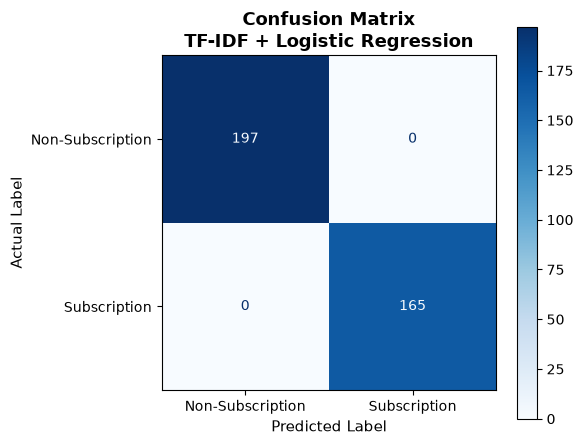

TF-IDF + Linear SVM
TN: 197
FP: 0
FN: 0
TP: 165


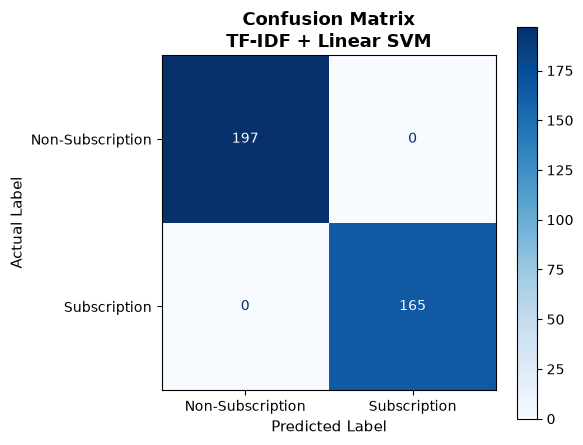

DistilBERT (Text Only)
TN: 197
FP: 0
FN: 0
TP: 165


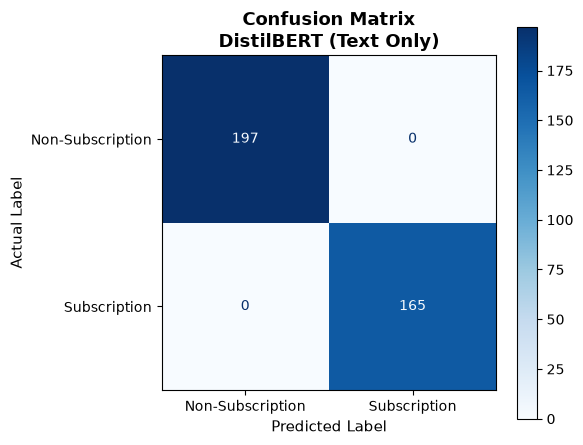

Recurrence Only (Threshold = 0.50)
TN: 197
FP: 0
FN: 160
TP: 5


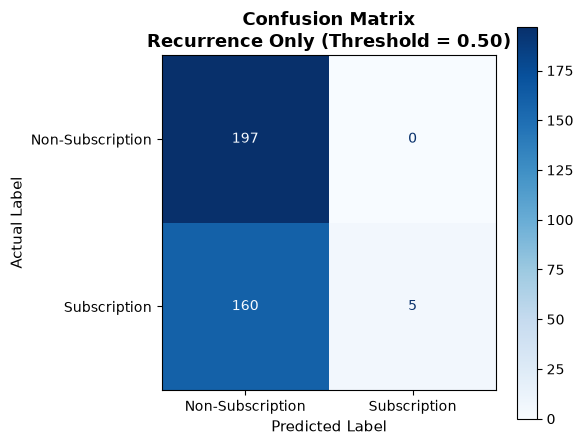

Optimized Hybrid
TN: 197
FP: 0
FN: 0
TP: 165


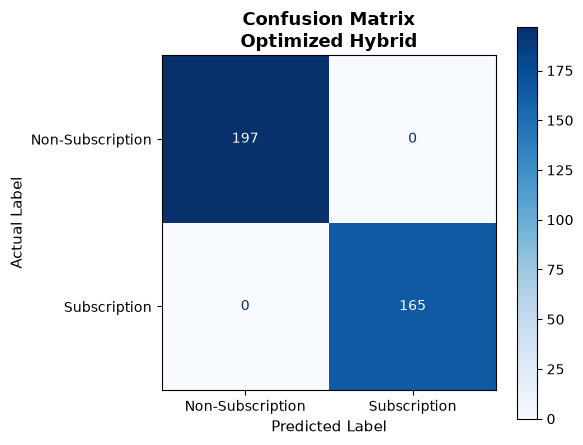

In [105]:
# ============================================================
# FINAL CONFUSION MATRICES - BLUE SHADE
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

# True labels
y_true = test_df["label"].astype(int)

# Predictions from all models
predictions = {
    "TF-IDF + Logistic Regression": logistic_pred,
    "TF-IDF + Linear SVM": svm_pred,
    "DistilBERT (Text Only)": distilbert_prediction,
    "Recurrence Only (Threshold = 0.50)": recurrence_prediction,
    "Optimized Hybrid": final_hybrid_prediction
}

# ============================================================
# GENERATE CONFUSION MATRICES
# ============================================================

for model_name, y_pred in predictions.items():

    # Calculate confusion matrix
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    # Print values
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(f"TN: {cm[0,0]}")
    print(f"FP: {cm[0,1]}")
    print(f"FN: {cm[1,0]}")
    print(f"TP: {cm[1,1]}")

    # Create figure
    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    # Display confusion matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Non-Subscription",
            "Subscription"
        ]
    )

    # BLUE SHADE
    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=True
    )

    # Title
    ax.set_title(
        f"Confusion Matrix\n{model_name}",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Predicted Label",
        fontsize=11
    )

    ax.set_ylabel(
        "Actual Label",
        fontsize=11
    )

    plt.tight_layout()
    plt.show()